# Pizza-Bot - Partie 3 : prévoir les ventes

Le distributeur pilote a tourné seize jours. Chaque jour, on a relevé la température extérieure
et le nombre de pizzas vendues. En dessous de 50 pizzas par jour, la machine perd de l'argent.

| Température (°C) | 3 | 5 | 6 | 8 | 10 | 11 | 13 | 15 | 17 | 18 | 20 | 22 | 24 | 26 | 28 | 31 |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| **Ventes** | 132 | 126 | 110 | 113 | 112 | 109 | 96 | 92 | 92 | 82 | 82 | 69 | 73 | 61 | 63 | 61 |

Règles du projet : Python de base, aucun import. Seules les cellules de tracé utilisent
matplotlib, et uniquement pour visualiser : aucun calcul n'y est fait.

## Étape 3.1 : le nuage d'abord

Le nuage se dessine à la main au brouillon. La cellule ci-dessous le retrace pour vérifier le
dessin. Le point moyen G partage le plan en quatre quadrants : en haut à droite et en bas à
gauche, le produit des écarts est positif ; dans les deux autres, il est négatif.

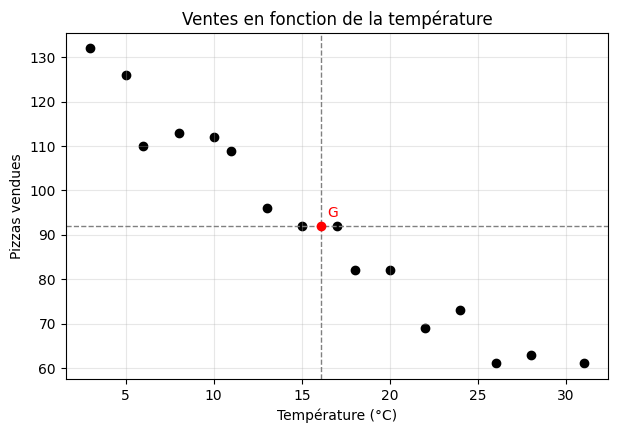

Point moyen G(16.06 ; 92.06)


In [1]:
# Cellule de visualisation uniquement : matplotlib ne sert qu'à tracer, pas à calculer.
import matplotlib.pyplot as plt

temperatures = [3, 5, 6, 8, 10, 11, 13, 15, 17, 18, 20, 22, 24, 26, 28, 31]
ventes = [132, 126, 110, 113, 112, 109, 96, 92, 92, 82, 82, 69, 73, 61, 63, 61]

x_moyen = sum(temperatures) / len(temperatures)
y_moyen = sum(ventes) / len(ventes)

plt.figure(figsize=(7, 4.5))
plt.scatter(temperatures, ventes, color="black")
plt.axvline(x_moyen, color="gray", linestyle="--", linewidth=1)
plt.axhline(y_moyen, color="gray", linestyle="--", linewidth=1)
plt.scatter([x_moyen], [y_moyen], color="red", zorder=5)
plt.text(x_moyen + 0.4, y_moyen + 2, "G", color="red")
plt.xlabel("Température (°C)")
plt.ylabel("Pizzas vendues")
plt.title("Ventes en fonction de la température")
plt.grid(alpha=0.3)
plt.show()

print(f"Point moyen G({x_moyen:.2f} ; {y_moyen:.2f})")

**Lecture du graphique.** Les points sont très nettement alignés, en descendant. Presque
tous se trouvent en haut à gauche et en bas à droite, donc dans les quadrants où le produit des
écarts est négatif : la covariance sera négative. À l'oeil, la droite perd une trentaine de
pizzas entre 5 et 20 °C, soit une pente d'environ -2 pizzas par degré.

## Étape 3.2 : moyenne, variance, covariance

In [2]:
temperatures = [3, 5, 6, 8, 10, 11, 13, 15, 17, 18, 20, 22, 24, 26, 28, 31]
ventes = [132, 126, 110, 113, 112, 109, 96, 92, 92, 82, 82, 69, 73, 61, 63, 61]

def moyenne(valeurs):
    return sum(valeurs) / len(valeurs)

def variance(valeurs):
    """V(X), en divisant par N."""
    m = moyenne(valeurs)
    total = 0
    for v in valeurs:
        total = total + (v - m) ** 2
    return total / len(valeurs)

def covariance(x, y):
    """cov(X, Y), en divisant par N. Les deux listes doivent avoir la même longueur."""
    if len(x) != len(y):
        raise ValueError("x et y n'ont pas la même longueur")
    mx = moyenne(x)
    my = moyenne(y)
    total = 0
    for xi, yi in zip(x, y):
        total = total + (xi - mx) * (yi - my)
    return total / len(x)

print(f"point moyen G({moyenne(temperatures):.4f} ; {moyenne(ventes):.4f})")
print(f"V(X) = {variance(temperatures):.3f}   V(Y) = {variance(ventes):.3f}")
print(f"cov(X, Y) = {covariance(temperatures, ventes):.3f}")

# --- Vérification : ne rien modifier sous cette ligne ---
assert moyenne([2, 4, 6]) == 4
assert abs(variance([2, 4, 6]) - 8 / 3) < 1e-9, "écarts -2, 0, 2 ; carrés 4, 0, 4 ; divisés par N = 3"
assert variance([5, 5, 5]) == 0, "une série constante ne varie pas"
assert abs(covariance([1, 2, 3], [2, 4, 6]) - 4 / 3) < 1e-9
assert abs(covariance([1, 2, 3], [6, 4, 2]) + 4 / 3) < 1e-9, "sens contraires : covariance négative"
assert abs(covariance(temperatures, temperatures) - variance(temperatures)) < 1e-9, "cov(X, X) = V(X)"
try:
    covariance([1, 2], [1, 2, 3])
    assert False, "des listes de longueurs différentes doivent lever une ValueError"
except ValueError:
    pass
print("Indicateurs validés")

point moyen G(16.0625 ; 92.0625)
V(X) = 69.684   V(Y) = 504.934
cov(X, Y) = -183.254
Indicateurs validés


**Lecture du résultat.** Le point moyen vaut G(16,06 ; 92,06), ce qui confirme la position
lue sur le nuage. La covariance vaut -183,25 : elle est bien négative, comme annoncé au
brouillon. Sa valeur ne s'interprète pas directement, car elle porte le produit des deux unités,
des degrés fois des pizzas.

## Étape 3.3 : corrélation et droite

In [3]:
temperatures = [3, 5, 6, 8, 10, 11, 13, 15, 17, 18, 20, 22, 24, 26, 28, 31]
ventes = [132, 126, 110, 113, 112, 109, 96, 92, 92, 82, 82, 69, 73, 61, 63, 61]

def moyenne(valeurs):
    return sum(valeurs) / len(valeurs)

def variance(valeurs):
    m = moyenne(valeurs)
    return sum((v - m) ** 2 for v in valeurs) / len(valeurs)

def covariance(x, y):
    mx, my = moyenne(x), moyenne(y)
    return sum((xi - mx) * (yi - my) for xi, yi in zip(x, y)) / len(x)

def coefficient_correlation(x, y):
    # sigma est la racine carrée de la variance
    sigma_x = variance(x) ** 0.5
    sigma_y = variance(y) ** 0.5
    return covariance(x, y) / (sigma_x * sigma_y)

def droite_moindres_carres(x, y):
    """Le couple (a, b) de la droite y = ax + b."""
    a = covariance(x, y) / variance(x)
    b = moyenne(y) - a * moyenne(x)
    return (a, b)

r = coefficient_correlation(temperatures, ventes)
a, b = droite_moindres_carres(temperatures, ventes)
print(f"r = {r:.3f}   r² = {r * r:.3f}")
print(f"ventes = {a:.3f} × température + {b:.2f}")

# Les trois contrôles du rappel, sous forme d'assert
# contrôle 1 : la droite passe par G
assert abs(a * moyenne(temperatures) + b - moyenne(ventes)) < 1e-9, "la droite doit passer par le point moyen G"
# contrôle 2 : a et r ont le même signe
assert (a < 0 and r < 0) or (a > 0 and r > 0), "a et r partagent le numérateur cov(X, Y) : même signe"
# contrôle 3 : |r| est assez grand pour que la droite serve
assert abs(r) > 0.8, "avec un |r| faible, la droite existe mais ne sert à rien"
print("Les trois contrôles passent")

# --- Vérification : ne rien modifier sous cette ligne ---
assert abs(coefficient_correlation([1, 2, 3], [5, 3, 1]) + 1) < 1e-9, "points parfaitement alignés en descendant : r = -1"
assert abs(coefficient_correlation([1, 2, 3, 4], [2, 1, 4, 3]) - 0.6) < 1e-9
pente, ordonnee = droite_moindres_carres([0, 1, 2, 3], [1, 3, 5, 7])
assert abs(pente - 2) < 1e-9 and abs(ordonnee - 1) < 1e-9, "les points sont exactement sur y = 2x + 1"
print("Corrélation et droite validées")

r = -0.977   r² = 0.954
ventes = -2.630 × température + 134.30
Les trois contrôles passent
Corrélation et droite validées


**Lecture du résultat.** r vaut -0,977, donc r² vaut 0,954 : la relation linéaire est très
forte et la droite a du sens. La pente vaut -2,63, proche des -2 estimés à l'oeil sur le nuage,
ce qui valide le calcul. Les trois contrôles du rappel passent : la droite passe par G, a et r
sont tous deux négatifs, et la corrélation dépasse largement 0,8 en valeur absolue.

### Le nuage avec la droite

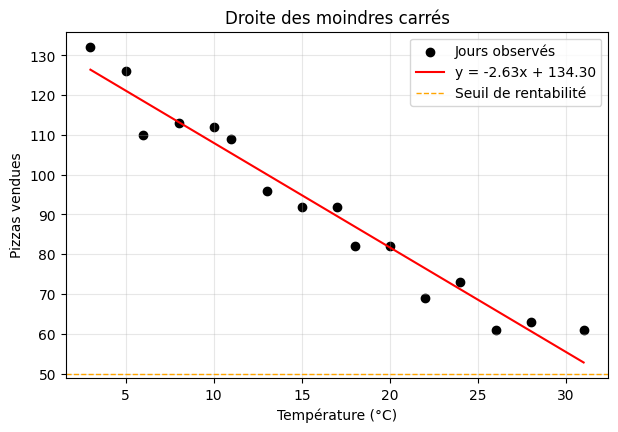

In [4]:
# Cellule de visualisation uniquement.
import matplotlib.pyplot as plt

temperatures = [3, 5, 6, 8, 10, 11, 13, 15, 17, 18, 20, 22, 24, 26, 28, 31]
ventes = [132, 126, 110, 113, 112, 109, 96, 92, 92, 82, 82, 69, 73, 61, 63, 61]

a = -2.6298342541436464
b = 134.30386740331492

x_droite = [3, 31]
y_droite = [a * 3 + b, a * 31 + b]

plt.figure(figsize=(7, 4.5))
plt.scatter(temperatures, ventes, color="black", label="Jours observés")
plt.plot(x_droite, y_droite, color="red", label=f"y = {a:.2f}x + {b:.2f}")
plt.axhline(50, color="orange", linestyle="--", linewidth=1, label="Seuil de rentabilité")
plt.xlabel("Température (°C)")
plt.ylabel("Pizzas vendues")
plt.title("Droite des moindres carrés")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Lecture du graphique.** La droite passe bien au milieu du nuage. Le seuil de rentabilité,
en pointillé, reste en dessous de toutes les journées observées : aucune n'a été déficitaire.

## Étape 3.4 : prédire, et jusqu'où

In [5]:
temperatures = [3, 5, 6, 8, 10, 11, 13, 15, 17, 18, 20, 22, 24, 26, 28, 31]
# Coefficients obtenus à l'étape 3.3, avec toutes leurs décimales.
a = -2.6298342541436464
b = 134.30386740331492
SEUIL_RENTABILITE = 50

def predire(a, b, x):
    return a * x + b

def dans_la_plage(x, observees):
    """True si x est dans la plage des valeurs observées, bornes comprises."""
    return min(observees) <= x <= max(observees)

for t in (22, 40):
    nature = "interpolation" if dans_la_plage(t, temperatures) else "EXTRAPOLATION"
    print(f"à {t} °C : {predire(a, b, t):.1f} pizzas ({nature})")

# La température à laquelle la droite vaut SEUIL_RENTABILITE : on résout a * t + b = 50.
t_seuil = (SEUIL_RENTABILITE - b) / a
print(f"{SEUIL_RENTABILITE} pizzas vers {t_seuil:.1f} °C : interpolation ? {dans_la_plage(t_seuil, temperatures)}")

# --- Vérification : ne rien modifier sous cette ligne ---
assert dans_la_plage(3, temperatures) is True and dans_la_plage(31, temperatures) is True, "les bornes sont observées"
assert dans_la_plage(2.9, temperatures) is False and dans_la_plage(35, temperatures) is False
assert abs(predire(a, b, t_seuil) - SEUIL_RENTABILITE) < 1e-6, "à t_seuil, la droite doit valoir exactement 50"
print("Prédiction validée")

à 22 °C : 76.4 pizzas (interpolation)
à 40 °C : 29.1 pizzas (EXTRAPOLATION)
50 pizzas vers 32.1 °C : interpolation ? False
Prédiction validée


**Lecture du résultat.** À 22 °C, la droite prévoit 76,4 pizzas : c'est une interpolation,
donc une prévision utilisable. À 40 °C, elle prévoit 29,1 pizzas, mais c'est une extrapolation,
hors de la plage 3 à 31 °C : rien ne garantit que la relation se prolonge. Le seuil de 50 pizzas
est atteint vers 32,1 °C, soit juste au-delà de la dernière journée observée, ce qui interdit
d'en faire une affirmation.